**Từ data 11k hand trên Kaggle - Dùng code dưới để phân loại ảnh tay úp, ngửa để để làm data**

In [ ]:
# ============================================================
# PHÂN LOẠI TÊN ẢNH — PALM vs DORSAL (chỉ xuất tên file)
# ============================================================

import pandas as pd
from google.colab import files

# ============================================================
# CẤU HÌNH
# ============================================================
CSV_PATH      = "/content/HandInfo.csv"  # upload CSV lên Colab rồi sửa tên nếu khác
OUTPUT_PALM   = "palm_images.txt"
OUTPUT_DORSAL = "dorsal_images.txt"
# ============================================================

PALM_LABELS   = {"palmar left", "palmar right"}
DORSAL_LABELS = {"dorsal left", "dorsal right"}

df = pd.read_csv(CSV_PATH)

palm_list   = df[df["aspectOfHand"].str.strip().str.lower().isin(PALM_LABELS)]["imageName"].tolist()
dorsal_list = df[df["aspectOfHand"].str.strip().str.lower().isin(DORSAL_LABELS)]["imageName"].tolist()

with open(OUTPUT_PALM, "w") as f:
    f.write("\n".join(palm_list))

with open(OUTPUT_DORSAL, "w") as f:
    f.write("\n".join(dorsal_list))

print(f"✅ Tổng ảnh       : {len(df)}")
print(f"🖐️  Ảnh Palm       : {len(palm_list)}")
print(f"✋  Ảnh Dorsal     : {len(dorsal_list)}")
print(f"⚠️  Không xác định : {len(df) - len(palm_list) - len(dorsal_list)}")

# Tự động tải 2 file về máy
files.download(OUTPUT_PALM)
files.download(OUTPUT_DORSAL)

✅ Tổng ảnh       : 11076
🖐️  Ảnh Palm       : 5396
✋  Ảnh Dorsal     : 5680
⚠️  Không xác định : 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**CODE CHÍNH**

1. Train model career

In [ ]:
# ============================================================
# CELL 1: CÀI THƯ VIỆN
# ============================================================
!pip install -q torch torchvision scikit-learn tqdm matplotlib

In [ ]:
# ============================================================
# CELL 2: IMPORT
# ============================================================
import os, json, copy, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_recall_fscore_support)
from tqdm import tqdm
from PIL import Image

print("✅ Import xong")

✅ Import xong


In [ ]:
# ============================================================
# CELL 3: CẤU HÌNH
# ============================================================
# --- Chỉ sửa các dòng này ---
DRIVE_BASE   = "/content/drive/MyDrive/Chi_Tay"
DATASET_DIR  = f"{DRIVE_BASE}/CAREER (Sự nghiệp)"   # ← đổi: love/career/finance/health
OUTPUT_DIR   = f"{DRIVE_BASE}/model_career"
# ----------------------------

BATCH_SIZE   = 32
IMG_SIZE     = 224
SEED         = 42
NUM_EPOCHS_1 = 20      # giai đoạn 1: freeze backbone
NUM_EPOCHS_2 = 20      # giai đoạn 2: fine-tune
LR_1         = 1e-3
LR_2         = 1e-4
PATIENCE     = 6
DROPOUT      = 0.3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print(f"✅ Device  : {DEVICE}")
print(f"✅ Dataset : {DATASET_DIR}")
print(f"✅ Output  : {OUTPUT_DIR}")

✅ Device  : cuda
✅ Dataset : /content/drive/MyDrive/Chi_Tay/CAREER (Sự nghiệp)
✅ Output  : /content/drive/MyDrive/Chi_Tay/model_career


In [ ]:
# ============================================================
# CELL 4: MOUNT GOOGLE DRIVE
# ============================================================


In [ ]:
# ============================================================
# CELL 5: LOAD DATASET + STRATIFIED SPLIT
# ============================================================
full_dataset = ImageFolder(root=DATASET_DIR)
class_names  = full_dataset.classes
num_classes  = len(class_names)
targets      = np.array(full_dataset.targets)
indices      = np.arange(len(targets))

# 80% train / 10% val / 10% test
idx_train, idx_temp = train_test_split(
    indices, test_size=0.2, stratify=targets, random_state=SEED)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.5, stratify=targets[idx_temp], random_state=SEED)

print(f"{'='*45}")
print(f"✅ Tổng ảnh    : {len(full_dataset)}")
print(f"✅ Số class    : {num_classes}")
print(f"✅ Train       : {len(idx_train)}")
print(f"✅ Validation  : {len(idx_val)}")
print(f"✅ Test        : {len(idx_test)}")
print(f"\n📊 Số ảnh mỗi class:")
for i, name in enumerate(class_names):
    print(f"   {name:25s}: {Counter(targets)[i]}")
print(f"{'='*45}")

# Lưu class names
with open(f"{OUTPUT_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("✅ Đã lưu class_names.json")

✅ Tổng ảnh    : 726
✅ Số class    : 3
✅ Train       : 580
✅ Validation  : 73
✅ Test        : 73

📊 Số ảnh mỗi class:
    stable                  : 239
   advancing                : 247
   building                 : 240
✅ Đã lưu class_names.json


In [ ]:
# ============================================================
# CELL 6: AUGMENTATION + DATALOADER
# ============================================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        path, label = self.dataset.samples[self.indices[idx]]  # ← đọc thẳng từ file
        img = Image.open(path).convert("RGB")                  # ← mở lại PIL Image
        return self.transform(img), label

# Không cần override full_dataset.transform nữa
train_ds = TransformSubset(full_dataset, idx_train, train_tf)
val_ds   = TransformSubset(full_dataset, idx_val,   val_tf)
test_ds  = TransformSubset(full_dataset, idx_test,  val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoader sẵn sàng")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ DataLoader sẵn sàng
   Train batches : 19
   Val batches   : 3
   Test batches  : 3


In [ ]:
# ============================================================
# CELL 7: BUILD MODEL — MobileNetV3-Small
# ============================================================
def build_model(num_classes, freeze_backbone=True):
    model = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Thay classifier head
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(p=DROPOUT),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes, freeze_backbone=True).to(DEVICE)

total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model: MobileNetV3-Small")
print(f"   Tổng params     : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
print(f"   Số class output : {num_classes}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 94.1MB/s]


✅ Model: MobileNetV3-Small
   Tổng params     : 1,075,491
   Trainable params: 148,483
   Số class output : 3


In [ ]:
# ============================================================
# CELL 8: HÀM TRAIN + EVALUATE
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs    = model(imgs)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

def run_training(model, train_loader, val_loader,
                 lr, num_epochs, phase_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)  # ← bỏ verbose=True

    history    = {"train_loss":[], "val_loss":[],
                  "train_acc":[],  "val_acc":[]}
    best_acc   = 0.0
    best_state = None
    no_improve = 0

    print(f"\n{'='*50}")
    print(f"🚀 {phase_name}")
    print(f"{'='*50}")

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step(v_acc)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        flag = ""
        if v_acc > best_acc:
            best_acc   = v_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, f"{OUTPUT_DIR}/best_model.pth")
            flag = " ✅ saved"
            no_improve = 0
        else:
            no_improve += 1

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train {t_acc:.4f} ({t_loss:.4f}) | "
              f"Val {v_acc:.4f} ({v_loss:.4f}){flag}")

        if no_improve >= PATIENCE:
            print(f"⏹️  Early stopping epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history

print("✅ Hàm train/evaluate sẵn sàng")

✅ Hàm train/evaluate sẵn sàng


In [ ]:
# ============================================================
# CELL 9: TRAINING LOOP
# ============================================================
def run_training(model, train_loader, val_loader,
                 lr, num_epochs, phase_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)  # ← đã xóa verbose=True

    history    = {"train_loss":[], "val_loss":[],
                  "train_acc":[],  "val_acc":[]}
    best_acc   = 0.0
    best_state = None
    no_improve = 0

    print(f"\n{'='*50}")
    print(f"🚀 {phase_name}")
    print(f"{'='*50}")

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step(v_acc)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        flag = ""
        if v_acc > best_acc:
            best_acc   = v_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, f"{OUTPUT_DIR}/best_model.pth")
            flag = " ✅ saved"
            no_improve = 0
        else:
            no_improve += 1

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train {t_acc:.4f} ({t_loss:.4f}) | "
              f"Val {v_acc:.4f} ({v_loss:.4f}){flag}")

        if no_improve >= PATIENCE:
            print(f"⏹️  Early stopping epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history

# GIAI ĐOẠN 1: Freeze backbone
model, hist1 = run_training(
    model, train_loader, val_loader,
    LR_1, NUM_EPOCHS_1, "GIAI ĐOẠN 1 — Freeze Backbone")


🚀 GIAI ĐOẠN 1 — Freeze Backbone


Epoch   1/20 | Train 0.4155 (1.0608) | Val 0.3425 (1.0974) ✅ saved


Epoch   2/20 | Train 0.5224 (0.9536) | Val 0.4795 (1.0467) ✅ saved


Epoch   3/20 | Train 0.5724 (0.9050) | Val 0.4658 (1.0854)


Epoch   4/20 | Train 0.5828 (0.8505) | Val 0.4521 (1.0234)


...

Epoch   9/20 | Train 0.6552 (0.7408) | Val 0.5068 (0.8560)


Epoch  10/20 | Train 0.6517 (0.7414) | Val 0.5616 (0.8408)


Epoch  11/20 | Train 0.6431 (0.7689) | Val 0.5479 (0.8385)


Epoch  12/20 | Train 0.6759 (0.7194) | Val 0.5479 (0.8178)


Epoch  13/20 | Train 0.7103 (0.7217) | Val 0.5479 (0.8073)
⏹️  Early stopping epoch 13


In [ ]:
# ============================================================
# CELL 10: FINE-TUNE TOÀN BỘ (GIAI ĐOẠN 2)
# ============================================================
print("🔓 Unfreeze toàn bộ model...")
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable params: {trainable:,}")

model, hist2 = run_training(
    model, train_loader, val_loader,
    LR_2, NUM_EPOCHS_2, "GIAI ĐOẠN 2 — Fine-tune Toàn Bộ")

🔓 Unfreeze toàn bộ model...
   Trainable params: 1,075,491

🚀 GIAI ĐOẠN 2 — Fine-tune Toàn Bộ


Epoch   1/20 | Train 0.6879 (0.7356) | Val 0.5205 (0.8329) ✅ saved


Epoch   2/20 | Train 0.6845 (0.6730) | Val 0.5616 (0.7834) ✅ saved


Epoch   3/20 | Train 0.7414 (0.5989) | Val 0.6712 (0.6866) ✅ saved


Epoch   4/20 | Train 0.7638 (0.5569) | Val 0.7397 (0.6444) ✅ saved


...

Epoch  16/20 | Train 0.8448 (0.3638) | Val 0.7945 (0.4953)


Epoch  17/20 | Train 0.8569 (0.3219) | Val 0.7534 (0.4670)


Epoch  18/20 | Train 0.8414 (0.3718) | Val 0.7260 (0.6642)


Epoch  19/20 | Train 0.8586 (0.3126) | Val 0.8082 (0.4921) ✅ saved


Epoch  20/20 | Train 0.8638 (0.3042) | Val 0.8082 (0.4705)


In [ ]:
# ============================================================
# CELL 11: ĐÁNH GIÁ TRÊN TẬP TEST
# ============================================================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc       = accuracy_score(all_labels, all_preds)
p, r, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted')

print(f"\n{'='*45}")
print(f"✅ Test Accuracy : {acc:.4f}")
print(f"✅ Precision     : {p:.4f}")
print(f"✅ Recall        : {r:.4f}")
print(f"✅ F1 Score      : {f1:.4f}")
print(f"{'='*45}")
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


✅ Test Accuracy : 0.8082
✅ Precision     : 0.8131
✅ Recall        : 0.8082
✅ F1 Score      : 0.8100

📋 Classification Report:
              precision    recall  f1-score   support

      stable       0.69      0.75      0.72        24
   advancing       0.96      0.92      0.94        25
    building       0.78      0.75      0.77        24

    accuracy                           0.81        73
   macro avg       0.81      0.81      0.81        73
weighted avg       0.81      0.81      0.81        73



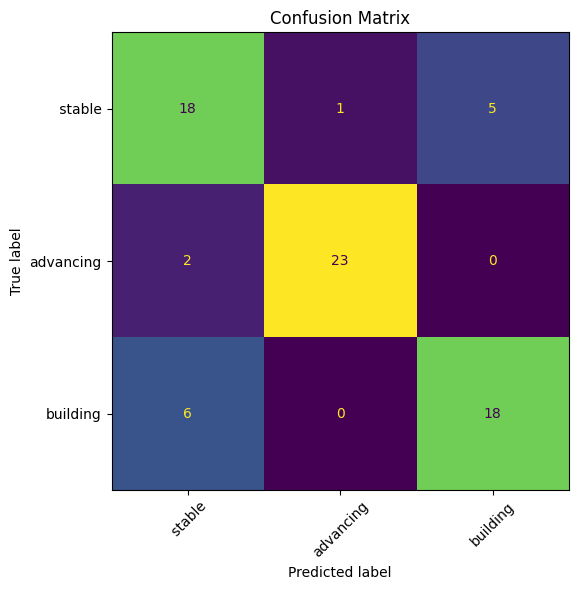

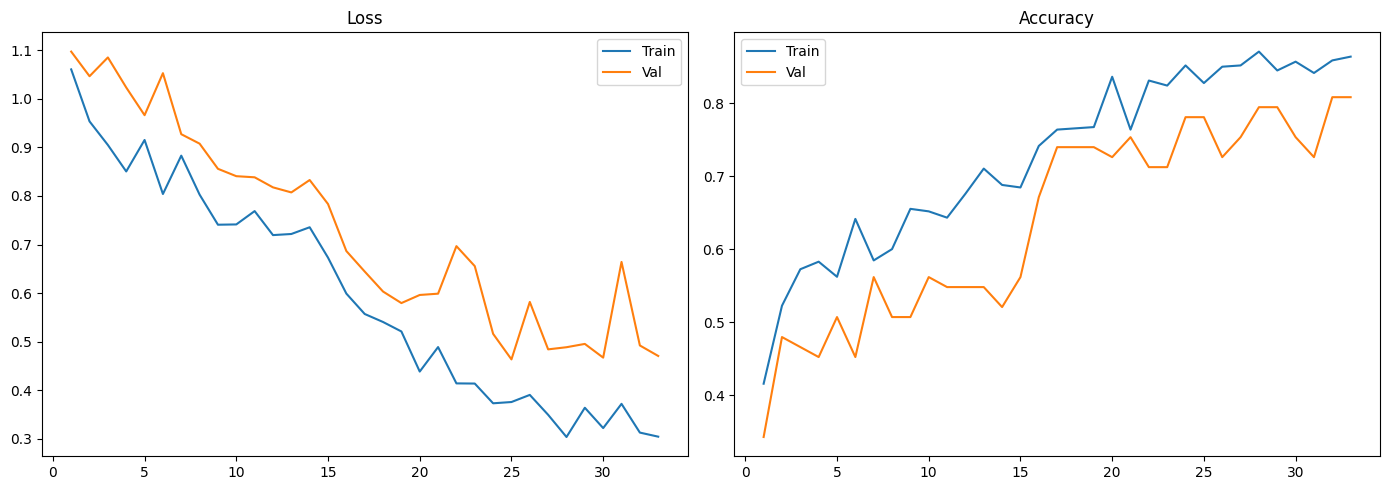

✅ Đã lưu biểu đồ → /content/drive/MyDrive/Chi_Tay/model_career/


In [ ]:
# ============================================================
# CELL 12: CONFUSION MATRIX + TRAINING CURVES
# ============================================================
# Confusion Matrix
cm   = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# Training Curves
history = {k: hist1[k] + hist2[k] for k in hist1}
epochs  = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()
print(f"✅ Đã lưu biểu đồ → {OUTPUT_DIR}/")

2. Train model finance

In [ ]:
# ============================================================
# CELL 3: CẤU HÌNH
# ============================================================
# --- Chỉ sửa các dòng này ---
DRIVE_BASE   = "/content/drive/MyDrive/Chi_Tay"
DATASET_DIR  = f"{DRIVE_BASE}/LOVE (Tình duyên)"   # ← đổi: love/career/finance/health
OUTPUT_DIR   = f"{DRIVE_BASE}/model_love"
# ----------------------------

BATCH_SIZE   = 32
IMG_SIZE     = 224
SEED         = 42
NUM_EPOCHS_1 = 20      # giai đoạn 1: freeze backbone
NUM_EPOCHS_2 = 20      # giai đoạn 2: fine-tune
LR_1         = 1e-3
LR_2         = 1e-4
PATIENCE     = 6
DROPOUT      = 0.3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print(f"✅ Device  : {DEVICE}")
print(f"✅ Dataset : {DATASET_DIR}")
print(f"✅ Output  : {OUTPUT_DIR}")

✅ Device  : cuda
✅ Dataset : /content/drive/MyDrive/Chi_Tay/LOVE (Tình duyên)
✅ Output  : /content/drive/MyDrive/Chi_Tay/model_love


In [ ]:
# ============================================================
# CELL 5: LOAD DATASET + STRATIFIED SPLIT
# ============================================================
full_dataset = ImageFolder(root=DATASET_DIR)
class_names  = full_dataset.classes
num_classes  = len(class_names)
targets      = np.array(full_dataset.targets)
indices      = np.arange(len(targets))

# 80% train / 10% val / 10% test
idx_train, idx_temp = train_test_split(
    indices, test_size=0.2, stratify=targets, random_state=SEED)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.5, stratify=targets[idx_temp], random_state=SEED)

print(f"{'='*45}")
print(f"✅ Tổng ảnh    : {len(full_dataset)}")
print(f"✅ Số class    : {num_classes}")
print(f"✅ Train       : {len(idx_train)}")
print(f"✅ Validation  : {len(idx_val)}")
print(f"✅ Test        : {len(idx_test)}")
print(f"\n📊 Số ảnh mỗi class:")
for i, name in enumerate(class_names):
    print(f"   {name:25s}: {Counter(targets)[i]}")
print(f"{'='*45}")

# Lưu class names
with open(f"{OUTPUT_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("✅ Đã lưu class_names.json")

✅ Tổng ảnh    : 726
✅ Số class    : 3
✅ Train       : 580
✅ Validation  : 73
✅ Test        : 73

📊 Số ảnh mỗi class:
   developing               : 238
   favorable                : 248
   need_nurturing           : 240
✅ Đã lưu class_names.json


In [ ]:
# ============================================================
# CELL 6: AUGMENTATION + DATALOADER
# ============================================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        path, label = self.dataset.samples[self.indices[idx]]  # ← đọc thẳng từ file
        img = Image.open(path).convert("RGB")                  # ← mở lại PIL Image
        return self.transform(img), label

# Không cần override full_dataset.transform nữa
train_ds = TransformSubset(full_dataset, idx_train, train_tf)
val_ds   = TransformSubset(full_dataset, idx_val,   val_tf)
test_ds  = TransformSubset(full_dataset, idx_test,  val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoader sẵn sàng")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ DataLoader sẵn sàng
   Train batches : 19
   Val batches   : 3
   Test batches  : 3


In [ ]:
# ============================================================
# CELL 7: BUILD MODEL — MobileNetV3-Small
# ============================================================
def build_model(num_classes, freeze_backbone=True):
    model = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Thay classifier head
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(p=DROPOUT),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes, freeze_backbone=True).to(DEVICE)

total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model: MobileNetV3-Small")
print(f"   Tổng params     : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
print(f"   Số class output : {num_classes}")

✅ Model: MobileNetV3-Small
   Tổng params     : 1,075,491
   Trainable params: 148,483
   Số class output : 3


In [ ]:
# ============================================================
# CELL 8: HÀM TRAIN + EVALUATE
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs    = model(imgs)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

def run_training(model, train_loader, val_loader,
                 lr, num_epochs, phase_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)  # ← bỏ verbose=True

    history    = {"train_loss":[], "val_loss":[],
                  "train_acc":[],  "val_acc":[]}
    best_acc   = 0.0
    best_state = None
    no_improve = 0

    print(f"\n{'='*50}")
    print(f"🚀 {phase_name}")
    print(f"{'='*50}")

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step(v_acc)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        flag = ""
        if v_acc > best_acc:
            best_acc   = v_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, f"{OUTPUT_DIR}/best_model.pth")
            flag = " ✅ saved"
            no_improve = 0
        else:
            no_improve += 1

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train {t_acc:.4f} ({t_loss:.4f}) | "
              f"Val {v_acc:.4f} ({v_loss:.4f}){flag}")

        if no_improve >= PATIENCE:
            print(f"⏹️  Early stopping epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history

print("✅ Hàm train/evaluate sẵn sàng")

✅ Hàm train/evaluate sẵn sàng


In [ ]:
# ============================================================
# CELL 9: TRAINING LOOP
# ============================================================
def run_training(model, train_loader, val_loader,
                 lr, num_epochs, phase_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)  # ← đã xóa verbose=True

    history    = {"train_loss":[], "val_loss":[],
                  "train_acc":[],  "val_acc":[]}
    best_acc   = 0.0
    best_state = None
    no_improve = 0

    print(f"\n{'='*50}")
    print(f"🚀 {phase_name}")
    print(f"{'='*50}")

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step(v_acc)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        flag = ""
        if v_acc > best_acc:
            best_acc   = v_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, f"{OUTPUT_DIR}/best_model.pth")
            flag = " ✅ saved"
            no_improve = 0
        else:
            no_improve += 1

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train {t_acc:.4f} ({t_loss:.4f}) | "
              f"Val {v_acc:.4f} ({v_loss:.4f}){flag}")

        if no_improve >= PATIENCE:
            print(f"⏹️  Early stopping epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history

# GIAI ĐOẠN 1: Freeze backbone
model, hist1 = run_training(
    model, train_loader, val_loader,
    LR_1, NUM_EPOCHS_1, "GIAI ĐOẠN 1 — Freeze Backbone")


🚀 GIAI ĐOẠN 1 — Freeze Backbone


Epoch   1/20 | Train 0.4379 (1.0501) | Val 0.3562 (1.1446) ✅ saved


Epoch   2/20 | Train 0.5655 (0.9370) | Val 0.4521 (0.9931) ✅ saved


Epoch   3/20 | Train 0.5328 (0.9301) | Val 0.4795 (0.9696) ✅ saved


Epoch   4/20 | Train 0.5914 (0.8820) | Val 0.4384 (1.1149)


...

Epoch  16/20 | Train 0.7190 (0.6165) | Val 0.7808 (0.6786)


Epoch  17/20 | Train 0.7259 (0.6686) | Val 0.7945 (0.6491) ✅ saved


Epoch  18/20 | Train 0.7293 (0.6678) | Val 0.5753 (1.1612)


Epoch  19/20 | Train 0.7103 (0.6632) | Val 0.7945 (0.6001)


Epoch  20/20 | Train 0.7638 (0.5685) | Val 0.7945 (0.5909)


In [ ]:
# ============================================================
# CELL 10: FINE-TUNE TOÀN BỘ (GIAI ĐOẠN 2)
# ============================================================
print("🔓 Unfreeze toàn bộ model...")
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable params: {trainable:,}")

model, hist2 = run_training(
    model, train_loader, val_loader,
    LR_2, NUM_EPOCHS_2, "GIAI ĐOẠN 2 — Fine-tune Toàn Bộ")

🔓 Unfreeze toàn bộ model...
   Trainable params: 1,075,491

🚀 GIAI ĐOẠN 2 — Fine-tune Toàn Bộ


Epoch   1/20 | Train 0.7621 (0.5779) | Val 0.7808 (0.6908) ✅ saved


Epoch   2/20 | Train 0.7897 (0.4951) | Val 0.7945 (0.5320) ✅ saved


Epoch   3/20 | Train 0.8310 (0.4222) | Val 0.7945 (0.5815)


Epoch   4/20 | Train 0.8500 (0.3835) | Val 0.8082 (0.4985) ✅ saved


...

Epoch  16/20 | Train 0.9069 (0.2430) | Val 0.9041 (0.2193) ✅ saved


Epoch  17/20 | Train 0.8759 (0.3038) | Val 0.8630 (0.3451)


Epoch  18/20 | Train 0.8966 (0.2398) | Val 0.8630 (0.3503)


Epoch  19/20 | Train 0.9086 (0.2205) | Val 0.9178 (0.2498) ✅ saved


Epoch  20/20 | Train 0.9034 (0.2218) | Val 0.9178 (0.2149)


In [ ]:
# ============================================================
# CELL 11: ĐÁNH GIÁ TRÊN TẬP TEST
# ============================================================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc       = accuracy_score(all_labels, all_preds)
p, r, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted')

print(f"\n{'='*45}")
print(f"✅ Test Accuracy : {acc:.4f}")
print(f"✅ Precision     : {p:.4f}")
print(f"✅ Recall        : {r:.4f}")
print(f"✅ F1 Score      : {f1:.4f}")
print(f"{'='*45}")
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


✅ Test Accuracy : 0.8356
✅ Precision     : 0.8431
✅ Recall        : 0.8356
✅ F1 Score      : 0.8376

📋 Classification Report:
                precision    recall  f1-score   support

    developing       0.73      0.79      0.76        24
     favorable       0.85      0.88      0.86        25
need_nurturing       0.95      0.83      0.89        24

      accuracy                           0.84        73
     macro avg       0.84      0.83      0.84        73
  weighted avg       0.84      0.84      0.84        73



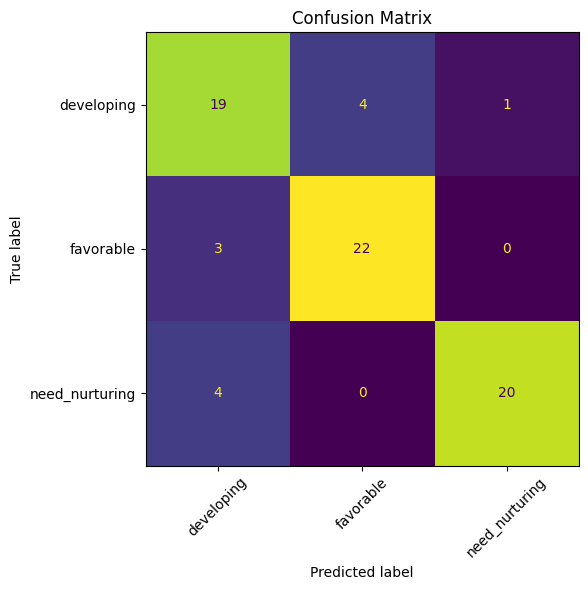

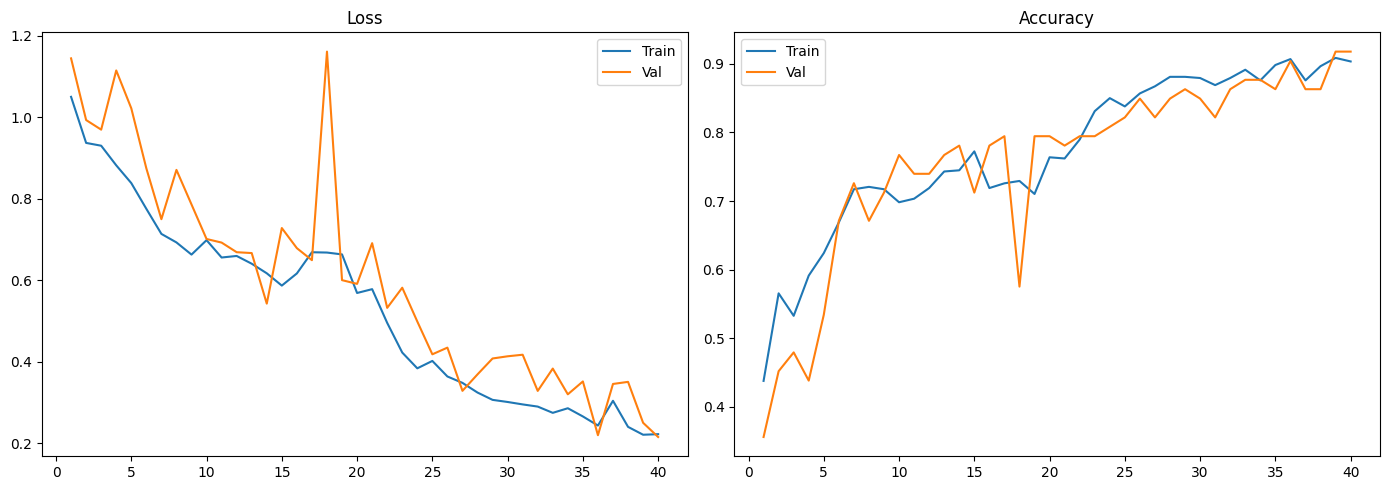

✅ Đã lưu biểu đồ → /content/drive/MyDrive/Chi_Tay/model_love/


In [ ]:
# ============================================================
# CELL 12: CONFUSION MATRIX + TRAINING CURVES
# ============================================================
# Confusion Matrix
cm   = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# Training Curves
history = {k: hist1[k] + hist2[k] for k in hist1}
epochs  = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()
print(f"✅ Đã lưu biểu đồ → {OUTPUT_DIR}/")

3. Train model health
# # Làm tương tự , chỉ thay đường dẫn 1 , 2

4. Train model love
# Làm tương tự , chỉ thay đường dẫn 1 , 2